# Proyek Analisis Data: E-Commerce Public Dataset
- **Nama:** Kevin Aditya Ikhsan
- **Email:** kevinadityaikhsan15@gmail.com
- **ID Dicoding:** kevinadityaikhsan

## 1. Menentukan Pertanyaan Bisnis

### 1.1. Project Context

The E-Commerce Public Dataset contains anonymized transactions from Olist, a Brazilian marketplace that connects small merchants to customers. The data covers orders, order items, payments, products, customers, and customer locations from September 2016 to October 2018.

Monthly order volume is very low before January 2017 and after August 2018 (fewer than 350 orders per month), so this project limits the analysis to **delivered orders purchased between 1 January 2017 and 31 August 2018** (20 complete months). Revenue figures are in Brazilian Real (BRL).

Two business problems define the scope of this project:
1. **Basket size.** Most orders contain a single item, which limits the value of each transaction.
2. **Customer retention.** Most customers buy only once, which limits customer lifetime value.

### 1.2. Business Questions

- **Pertanyaan 1:** During January 2017 – August 2018, how much higher is the median order value of delivered orders containing two or more items compared with single-item orders, and which product categories appear most often in those multi-item orders?
- **Pertanyaan 2:** During January 2017 – August 2018, what percentage of customers placed more than one delivered order, and how much higher is the total spending (payment value) of these repeat customers compared with one-time customers?

Each question is defined along the five SMART elements:

| Element | Pertanyaan 1 (Basket Size) | Pertanyaan 2 (Customer Retention) |
| --- | --- | --- |
| **Specific** | Order value of delivered orders, grouped by the number of items per order. | Repeat purchase rate and total spending of one-time versus repeat customers. |
| **Measurable** | Median order value (BRL) per item group, difference in BRL and %, and the number of multi-item orders per category. | Percentage of repeat customers, and median total spending (BRL) per customer group. |
| **Action-Oriented** | Identifies the categories to use in bundling and cross-selling programs that increase items per order. | Measures the spending gap between the two groups and the number of customers a retention program would target. |
| **Relevant** | Most orders contain one item, which limits revenue per transaction. | Most customers buy once, which limits revenue per customer. |
| **Time-bound** | January 2017 – August 2018. | January 2017 – August 2018. |

## 2. Import Semua Packages/Library yang Digunakan

In [1]:
import unicodedata

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from scipy import stats

import warnings
warnings.filterwarnings('ignore')

# Display settings.
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:,.2f}'.format)

# Analysis scope and reproducibility.
DATA_DIR = 'data'
START_DATE = pd.Timestamp('2017-01-01')
END_DATE = pd.Timestamp('2018-08-31 23:59:59')
RANDOM_STATE = 42

# Chart style shared by every visualization: one highlight color for the key
# message, one secondary color for comparisons, and gray for context.
HIGHLIGHT = '#2a78d6'
SECONDARY = '#eb6834'
MUTED = '#c7c7c7'
TEXT = '#0b0b0b'
sns.set_theme(style='white', rc={
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titleweight': 'bold',
    'axes.titlesize': 13,
    'axes.titlepad': 12,
    'axes.labelcolor': '#52514e',
    'xtick.color': '#52514e',
    'ytick.color': '#52514e',
})

### 2.1. Helper Functions

The functions below are reused across the notebook to keep each analysis step short and consistent:

* `summarize`: data type, missing values, and unique values per column (used in Assessing Data).
* `iqr_bounds`: lower and upper outlier limits using the 1.5 × IQR rule.
* `normalize_text`: lowercase, trimmed, accent-free text used to detect inconsistent spellings.
* `bootstrap_median_ci`: 95% bootstrap confidence interval of a median.
* `annotate_bars`: writes the value on each bar so readers do not have to estimate it from the axis.

In [2]:
def summarize(df):
    """Return data type, missing values, and unique values for each column."""
    return pd.DataFrame({
        'dtype': df.dtypes.astype(str),
        'missing': df.isna().sum(),
        'missing_pct': (df.isna().mean() * 100).round(2),
        'unique': df.nunique(),
    })


def iqr_bounds(series):
    """Return the lower and upper outlier limits based on the 1.5 x IQR rule."""
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    return q1 - 1.5 * iqr, q3 + 1.5 * iqr


def normalize_text(series):
    """Lowercase, trim, and remove accents (e.g. 'São Paulo' -> 'sao paulo')."""
    return series.str.lower().str.strip().map(
        lambda text: unicodedata.normalize('NFKD', text).encode('ascii', 'ignore').decode()
    )


def bootstrap_median_ci(values, n_boot=1000, seed=RANDOM_STATE):
    """Return the median and its 95% bootstrap confidence interval."""
    rng = np.random.default_rng(seed)
    values = np.asarray(values)
    medians = [np.median(rng.choice(values, size=len(values), replace=True)) for _ in range(n_boot)]
    return np.median(values), np.percentile(medians, 2.5), np.percentile(medians, 97.5)


def annotate_bars(ax, fmt='{:,.0f}', inside=False):
    """Write each bar's value at the end of the bar (or inside it when error bars are drawn)."""
    for container in ax.containers:
        if isinstance(container, mpl.container.BarContainer):
            ax.bar_label(container, labels=[fmt.format(v) for v in container.datavalues],
                         label_type='center' if inside else 'edge', padding=0 if inside else 3,
                         fontsize=10, color=TEXT, fontweight='bold' if inside else 'normal')

## 3. Data Wrangling

### 3.1. Gathering Data

The analysis uses 7 of the 9 tables in the dataset. The sellers and order reviews tables are not loaded because neither business question depends on them.

| Table | Content | Used for |
| --- | --- | --- |
| `customers_dataset.csv` | Customer identifiers and location | Repeat customers, geography |
| `orders_dataset.csv` | Order status and timestamps | Analysis period, order count |
| `order_items_dataset.csv` | Items, price, and freight per order | Basket size, order value |
| `order_payments_dataset.csv` | Payment method and value per order | Customer spending |
| `products_dataset.csv` | Product attributes and category | Product categories |
| `product_category_name_translation.csv` | Portuguese to English category names | Readable category names |
| `geolocation_dataset.csv` | Latitude and longitude per zip code prefix | Geospatial analysis |

#### 3.1.1. Load customers_df

In [3]:
customers_df = pd.read_csv(f'{DATA_DIR}/customers_dataset.csv')
customers_df.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


#### 3.1.2. Load orders_df

In [4]:
orders_df = pd.read_csv(f'{DATA_DIR}/orders_dataset.csv')
orders_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


#### 3.1.3. Load order_items_df

In [5]:
order_items_df = pd.read_csv(f'{DATA_DIR}/order_items_dataset.csv')
order_items_df.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


#### 3.1.4. Load order_payments_df

In [6]:
order_payments_df = pd.read_csv(f'{DATA_DIR}/order_payments_dataset.csv')
order_payments_df.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


#### 3.1.5. Load products_df

In [7]:
products_df = pd.read_csv(f'{DATA_DIR}/products_dataset.csv')
products_df.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.00,287.00,1.00,225.00,16.00,10.00,14.00
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.00,276.00,1.00,"1,000.00",30.00,18.00,20.00
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.00,250.00,1.00,154.00,18.00,9.00,15.00
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.00,261.00,1.00,371.00,26.00,4.00,26.00
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.00,402.00,4.00,625.00,20.00,17.00,13.00


#### 3.1.6. Load category_translation_df

In [8]:
category_translation_df = pd.read_csv(f'{DATA_DIR}/product_category_name_translation.csv')
category_translation_df.head()

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


#### 3.1.7. Load geolocation_df

In [9]:
geolocation_df = pd.read_csv(f'{DATA_DIR}/geolocation_dataset.csv')
geolocation_df.head()

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.55,-46.64,sao paulo,SP
1,1046,-23.55,-46.64,sao paulo,SP
2,1046,-23.55,-46.64,sao paulo,SP
3,1041,-23.54,-46.64,sao paulo,SP
4,1035,-23.54,-46.64,sao paulo,SP


In [10]:
tables = {
    'customers_df': customers_df,
    'orders_df': orders_df,
    'order_items_df': order_items_df,
    'order_payments_df': order_payments_df,
    'products_df': products_df,
    'category_translation_df': category_translation_df,
    'geolocation_df': geolocation_df,
}
pd.DataFrame(
    {'rows': [len(df) for df in tables.values()], 'columns': [df.shape[1] for df in tables.values()]},
    index=tables.keys(),
)

,rows,columns
customers_df,99441,5
orders_df,99441,8
order_items_df,112650,7
order_payments_df,103886,5
products_df,32951,9
category_translation_df,71,2
geolocation_df,1000163,5


**Insight:**
- All 7 tables were loaded into DataFrames: `customers_df` and `orders_df` (99,441 rows each), `order_items_df` (112,650 rows), `order_payments_df` (103,886 rows), `products_df` (32,951 rows), `category_translation_df` (71 rows), and `geolocation_df` (1,000,163 rows).
- The tables connect through shared keys: `customer_id` (customers ↔ orders), `order_id` (orders ↔ items and payments), `product_id` (items ↔ products), `product_category_name` (products ↔ translation), and the zip code prefix (customers ↔ geolocation).
- `orders_df` and `customers_df` have the same number of rows because a new `customer_id` is generated for every order. The person behind the order is identified by `customer_unique_id`.
- `order_items_df` and `order_payments_df` have more rows than `orders_df` because one order can contain several items and several payments.

### 3.2. Assessing Data

#### 3.2.1. Identifying problems in customers_df

In [11]:
summarize(customers_df)

,dtype,missing,missing_pct,unique
customer_id,str,0,0.00,99441
customer_unique_id,str,0,0.00,96096
customer_zip_code_prefix,int64,0,0.00,14994
customer_city,str,0,0.00,4119
customer_state,str,0,0.00,27


In [12]:
print('Duplicate rows:', customers_df.duplicated().sum())
print('Duplicate customer_id:', customers_df['customer_id'].duplicated().sum())
print('Unique customers (customer_unique_id):', customers_df['customer_unique_id'].nunique())
print('Customer cities changed by normalization:',
      (normalize_text(customers_df['customer_city']) != customers_df['customer_city']).sum())

Duplicate rows: 0
Duplicate customer_id: 0
Unique customers (customer_unique_id): 96096
Customer cities changed by normalization: 0


- No missing values, no duplicate rows, and no duplicate `customer_id`.
- 99,441 `customer_id` values belong to 96,096 `customer_unique_id` values. This is the dataset's design (one `customer_id` per order), not a data error, but it means **repeat customers must be counted with `customer_unique_id`**.
- City names are already lowercase and accent-free (0 values change after normalization).
- **Result:** no cleaning is required for `customers_df`.

#### 3.2.2. Identifying problems in orders_df

In [13]:
summarize(orders_df)

,dtype,missing,missing_pct,unique
order_id,str,0,0.00,99441
customer_id,str,0,0.00,99441
order_status,str,0,0.00,8
order_purchase_timestamp,str,0,0.00,98875
order_approved_at,str,160,0.16,90733
order_delivered_carrier_date,str,1783,1.79,81018
order_delivered_customer_date,str,2965,2.98,95664
order_estimated_delivery_date,str,0,0.00,459


In [14]:
timestamp_cols = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date',
]
print('Duplicate order_id:', orders_df['order_id'].duplicated().sum())

# Missing timestamps per order status.
missing_by_status = orders_df[timestamp_cols].isna().groupby(orders_df['order_status']).sum()
missing_by_status.assign(orders=orders_df['order_status'].value_counts()).sort_values('orders', ascending=False)

Duplicate order_id: 0


,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,orders
order_status,,,,,,
delivered,0,14,2,8,0,96478
shipped,0,0,0,1107,0,1107
canceled,0,141,550,619,0,625
unavailable,0,0,609,609,0,609
invoiced,0,0,314,314,0,314
processing,0,0,301,301,0,301
created,0,5,5,5,0,5
approved,0,0,2,2,0,2


- No duplicate `order_id`.
- **Data type problem:** all five timestamp columns are stored as text (`str`) instead of datetime.
- **Missing values:** `order_approved_at` (160), `order_delivered_carrier_date` (1,783), and `order_delivered_customer_date` (2,965). Most of them belong to orders that were never delivered (shipped, canceled, unavailable, invoiced, processing). Among delivered orders, only 14, 2, and 8 values are missing in these columns.
- The analysis uses only `order_purchase_timestamp` (no missing values) and the `order_status` of delivered orders, so the missing timestamps do not affect the results. They are kept as they are, because filling them would create dates that never happened.

#### 3.2.3. Identifying problems in order_items_df

In [15]:
summarize(order_items_df)

,dtype,missing,missing_pct,unique
order_id,str,0,0.00,98666
order_item_id,int64,0,0.00,21
product_id,str,0,0.00,32951
seller_id,str,0,0.00,3095
shipping_limit_date,str,0,0.00,93318
price,float64,0,0.00,5968
freight_value,float64,0,0.00,6999


In [16]:
print('Duplicate (order_id, order_item_id):',
      order_items_df.duplicated(subset=['order_id', 'order_item_id']).sum())

for col in ['price', 'freight_value']:
    lower, upper = iqr_bounds(order_items_df[col])
    outliers = order_items_df[(order_items_df[col] < lower) | (order_items_df[col] > upper)]
    print(f'{col}: upper limit {upper:,.2f} BRL, outliers {len(outliers):,} '
          f'({len(outliers) / len(order_items_df):.2%}), max {order_items_df[col].max():,.2f} BRL')

order_items_df[['price', 'freight_value']].describe()

Duplicate (order_id, order_item_id): 0
price: upper limit 277.40 BRL, outliers 8,427 (7.48%), max 6,735.00 BRL
freight_value: upper limit 33.25 BRL, outliers 12,134 (10.77%), max 409.68 BRL


,price,freight_value
count,"112,650.00","112,650.00"
mean,120.65,19.99
std,183.63,15.81
min,0.85,0.00
25%,39.90,13.08
50%,74.99,16.26
75%,134.90,21.15
max,"6,735.00",409.68


- No missing values and no duplicate (`order_id`, `order_item_id`) pairs.
- **Data type problem:** `shipping_limit_date` is stored as text.
- **Outliers:** 8,427 prices (7.48%) are above the 1.5 × IQR limit of 277.40 BRL (maximum 6,735.00 BRL), and 12,134 freight values (10.77%) are above 33.25 BRL (maximum 409.68 BRL). 383 items have a freight value of 0.
- The highest prices belong to expensive product types, such as housewares, computers, art, and small appliances, so they are valid values rather than entry errors. They are **kept**. To limit their influence, the analysis uses medians and non-parametric statistical tests.

#### 3.2.4. Identifying problems in order_payments_df

In [17]:
summarize(order_payments_df)

,dtype,missing,missing_pct,unique
order_id,str,0,0.00,99440
payment_sequential,int64,0,0.00,29
payment_type,str,0,0.00,5
payment_installments,int64,0,0.00,24
payment_value,float64,0,0.00,29077


In [18]:
print('Duplicate (order_id, payment_sequential):',
      order_payments_df.duplicated(subset=['order_id', 'payment_sequential']).sum())
print('Orders with more than one payment row:',
      (order_payments_df['order_id'].value_counts() > 1).sum())
print()
print('Payment type distribution:')
print(order_payments_df['payment_type'].value_counts().to_string())

Duplicate (order_id, payment_sequential): 0
Orders with more than one payment row: 2961

Payment type distribution:
payment_type
credit_card    76795
boleto         19784
voucher         5775
debit_card      1529
not_defined        3


In [19]:
# Invalid values: an undefined payment type and payments with zero installments.
order_payments_df[
    (order_payments_df['payment_type'] == 'not_defined')
    | (order_payments_df['payment_installments'] == 0)
]

,order_id,payment_sequential,payment_type,payment_installments,payment_value
46982,744bade1fcf9ff3f31d860ace076d422,2,credit_card,0,58.69
51280,4637ca194b6387e2d538dc89b124b0ee,1,not_defined,1,0.00
57411,00b1cb0320190ca0daa2c88b35206009,1,not_defined,1,0.00
79014,1a57108394169c0b47d8f876acc9ba2d,2,credit_card,0,129.94
94427,c8c528189310eaa44a745b8d9d26908b,1,not_defined,1,0.00


In [20]:
# Zero-value payments by payment type.
order_payments_df[order_payments_df['payment_value'] == 0]['payment_type'].value_counts()

payment_type
voucher        6
not_defined    3
Name: count, dtype: int64

- No missing values and no duplicate (`order_id`, `payment_sequential`) pairs.
- 2,961 orders have more than one payment row (for example, a credit card combined with a voucher). **Payments must be summed per order** before they are joined to orders.
- **Invalid value:** 3 rows have `payment_type = "not_defined"`, all with a payment value of 0.
- **Invalid value:** 2 credit card payments have `payment_installments = 0`. A paid order has at least one installment.
- 6 voucher payments have a value of 0. All of them belong to orders that also have other payments with a positive total, so they do not change any order total and are kept.

#### 3.2.5. Identifying problems in products_df and category_translation_df

In [21]:
summarize(products_df)

,dtype,missing,missing_pct,unique
product_id,str,0,0.00,32951
product_category_name,str,610,1.85,73
product_name_lenght,float64,610,1.85,66
product_description_lenght,float64,610,1.85,2960
product_photos_qty,float64,610,1.85,19
product_weight_g,float64,2,0.01,2204
product_length_cm,float64,2,0.01,99
product_height_cm,float64,2,0.01,102
product_width_cm,float64,2,0.01,95


In [22]:
categories = products_df['product_category_name'].dropna().unique()
variant_categories = sorted(c for c in categories if c.endswith('_2'))
print('Category variants with a "_2" suffix:', variant_categories)
print(products_df['product_category_name']
      .isin(variant_categories + [c[:-2] for c in variant_categories])
      .pipe(lambda mask: products_df[mask]['product_category_name'].value_counts())
      .to_string())
print()
print('Categories without an English translation:',
      sorted(set(categories) - set(category_translation_df['product_category_name'])))

Category variants with a "_2" suffix: ['casa_conforto_2', 'eletrodomesticos_2']
product_category_name
eletrodomesticos      370
casa_conforto         111
eletrodomesticos_2     90
casa_conforto_2         5

Categories without an English translation: ['pc_gamer', 'portateis_cozinha_e_preparadores_de_alimentos']


In [23]:
# Spelling issues in the English category names.
category_translation_df[
    category_translation_df['product_category_name_english'].str.contains('fashio_|confort|_2$')
]

,product_category_name,product_category_name_english
35,casa_conforto,home_confort
55,fashion_roupa_feminina,fashio_female_clothing
56,eletrodomesticos_2,home_appliances_2
62,casa_conforto_2,home_comfort_2


- **Missing values:** 610 products (1.85%) have no `product_category_name`. The same 610 products also have no name length, description length, or photo count, and 2 products have no weight or dimensions.
- **Inconsistent values:** two categories have a duplicate `_2` variant: `eletrodomesticos` (370 products) and `eletrodomesticos_2` (90), and `casa_conforto` (111) and `casa_conforto_2` (5).
- **Missing reference values:** `pc_gamer` and `portateis_cozinha_e_preparadores_de_alimentos` have no English translation.
- **Inconsistent values:** the English names contain spelling errors (`fashio_female_clothing`, `home_confort`) and `_2` duplicates (`home_appliances_2`, `home_comfort_2`).
- Product name length, description length, photo count, weight, and dimensions are not used by the business questions.

#### 3.2.6. Identifying problems in geolocation_df

In [24]:
summarize(geolocation_df)

,dtype,missing,missing_pct,unique
geolocation_zip_code_prefix,int64,0,0.00,19015
geolocation_lat,float64,0,0.00,717360
geolocation_lng,float64,0,0.00,717613
geolocation_city,str,0,0.00,8011
geolocation_state,str,0,0.00,27


In [25]:
# Brazil's bounding box (approximate extreme points of the country).
LAT_RANGE, LNG_RANGE = (-33.75, 5.27), (-73.99, -34.79)
outside_brazil = ~(
    geolocation_df['geolocation_lat'].between(*LAT_RANGE)
    & geolocation_df['geolocation_lng'].between(*LNG_RANGE)
)

print('Duplicate rows:', geolocation_df.duplicated().sum())
print('Rows per zip code prefix (mean):',
      round(len(geolocation_df) / geolocation_df['geolocation_zip_code_prefix'].nunique(), 1))
print('Coordinates outside Brazil:', outside_brazil.sum())
print('Unique city names (raw):', geolocation_df['geolocation_city'].nunique())
print('Unique city names (normalized):', normalize_text(geolocation_df['geolocation_city']).nunique())
print('Customer zip prefixes without coordinates:',
      (~customers_df['customer_zip_code_prefix'].isin(geolocation_df['geolocation_zip_code_prefix'])).sum())

Duplicate rows: 261831
Rows per zip code prefix (mean): 52.6
Coordinates outside Brazil: 42
Unique city names (raw): 8011


Unique city names (normalized): 5967
Customer zip prefixes without coordinates: 278


- **Duplicate data:** 261,831 rows are exact duplicates.
- Each zip code prefix has 52.6 rows on average because the table stores many coordinate points per prefix. Joining it to customers as it is would multiply the order rows, so it needs **one point per zip code prefix**.
- **Inaccurate values:** 42 coordinates fall outside Brazil's geographic boundaries.
- **Inconsistent values:** there are 8,011 raw city names but only 5,967 after normalization (for example, "são paulo" and "sao paulo"). The city column is not needed because `customers_df` already provides clean city names.
- 278 customer zip code prefixes have no coordinates. Orders from these zip codes can be included in every analysis except the map.

**Steps to Take:**
- `orders_df`: convert the five timestamp columns to datetime. Keep the missing timestamps as they are.
- `order_items_df`: convert `shipping_limit_date` to datetime. Keep price and freight outliers.
- `order_payments_df`: remove the 3 `not_defined` rows and set the 2 zero-installment values to 1. Sum payments per order during EDA.
- `products_df`: merge the `_2` categories into their base category, add the 2 missing translations, fix the English spelling errors, label missing categories as `unknown`, and keep only the columns used in the analysis.
- `geolocation_df`: drop exact duplicates, remove the 42 coordinates outside Brazil, and keep one median coordinate per zip code prefix.
- `customers_df`: no action required. Use `customer_unique_id` to identify customers.

**Insight:**
- Six types of data quality problems were found: incorrect data types (orders, order items), missing values (orders, products), duplicate data (geolocation), invalid values (payments), inaccurate values (geolocation), and inconsistent values (product categories, geolocation cities).
- Outliers in price and freight value are real business values and are kept.
- Two structural characteristics must be handled in the analysis: customers are identified by `customer_unique_id`, and payments must be summed per order.

### 3.3. Cleaning Data

#### 3.3.1. Fixing data type problem in orders_df and order_items_df

In [26]:
for col in timestamp_cols:
    orders_df[col] = pd.to_datetime(orders_df[col])
order_items_df['shipping_limit_date'] = pd.to_datetime(order_items_df['shipping_limit_date'])

pd.concat([orders_df[timestamp_cols].dtypes, order_items_df[['shipping_limit_date']].dtypes])

order_purchase_timestamp         datetime64[us]
order_approved_at                datetime64[us]
order_delivered_carrier_date     datetime64[us]
order_delivered_customer_date    datetime64[us]
order_estimated_delivery_date    datetime64[us]
shipping_limit_date              datetime64[us]
dtype: object

All five order timestamp columns and `shipping_limit_date` now use the `datetime64` type, so they can be filtered by period and grouped by month.

#### 3.3.2. Fixing invalid value problem in order_payments_df

In [27]:
order_payments_df = order_payments_df[order_payments_df['payment_type'] != 'not_defined'].copy()
order_payments_df.loc[order_payments_df['payment_installments'] == 0, 'payment_installments'] = 1

print('Rows with payment_type "not_defined":', (order_payments_df['payment_type'] == 'not_defined').sum())
print('Rows with 0 installments:', (order_payments_df['payment_installments'] == 0).sum())
print('Rows remaining:', len(order_payments_df))

Rows with payment_type "not_defined": 0
Rows with 0 installments: 0
Rows remaining: 103883


The 3 `not_defined` payments were removed, and the 2 payments with 0 installments now have 1 installment. `order_payments_df` now has 103,883 rows and only valid payment types.

#### 3.3.3. Fixing inconsistent value and missing value problems in products_df

In [28]:
# Fix spelling issues in the English names and add the two missing translations.
category_translation_df['product_category_name_english'] = (
    category_translation_df['product_category_name_english'].replace({
        'fashio_female_clothing': 'fashion_female_clothing',
        'home_confort': 'home_comfort',
        'home_comfort_2': 'home_comfort',
        'home_appliances_2': 'home_appliances',
    })
)
category_translation_df = pd.concat([
    category_translation_df,
    pd.DataFrame({
        'product_category_name': ['pc_gamer', 'portateis_cozinha_e_preparadores_de_alimentos'],
        'product_category_name_english': ['pc_gamer', 'portable_kitchen_food_preparers'],
    }),
], ignore_index=True)

# Merge "_2" variants into their base category, translate, and label missing categories.
products_df['product_category_name'] = products_df['product_category_name'].str.replace(
    r'_2$', '', regex=True
)
products_df = products_df.merge(category_translation_df, on='product_category_name', how='left')
products_df['product_category'] = products_df['product_category_name_english'].fillna('unknown')

# Keep only the columns used in the analysis.
products_df = products_df[['product_id', 'product_category']]

print('Missing categories:', products_df['product_category'].isna().sum())
print('Products labeled "unknown":', (products_df['product_category'] == 'unknown').sum())
print('Unique categories:', products_df['product_category'].nunique())

Missing categories: 0
Products labeled "unknown": 610
Unique categories: 72


- The `_2` variants were merged into their base categories, the two missing translations were added, and the English spelling errors were corrected.
- The 610 products without a category are labeled `unknown`. This keeps them in order-value calculations while identifying them as uncategorized in category-level results.
- `products_df` now contains only `product_id` and the English `product_category` (71 categories plus `unknown`), with no missing values.

#### 3.3.4. Fixing duplicate and inaccurate value problems in geolocation_df

In [29]:
geolocation_df = geolocation_df.drop_duplicates()
geolocation_df = geolocation_df[
    geolocation_df['geolocation_lat'].between(*LAT_RANGE)
    & geolocation_df['geolocation_lng'].between(*LNG_RANGE)
]

# One representative point (median coordinate) per zip code prefix.
geolocation_df = geolocation_df.groupby('geolocation_zip_code_prefix', as_index=False).agg(
    geolocation_lat=('geolocation_lat', 'median'),
    geolocation_lng=('geolocation_lng', 'median'),
)

print('Rows:', len(geolocation_df))
print('Duplicate zip code prefixes:', geolocation_df['geolocation_zip_code_prefix'].duplicated().sum())
geolocation_df.describe()

Rows: 19010
Duplicate zip code prefixes: 0


,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng
count,"19,010.00","19,010.00","19,010.00"
mean,"42,705.53",-19.08,-46.08
std,"30,903.69",7.24,5.20
min,"1,001.00",-33.69,-72.91
25%,"12,720.25",-23.56,-49.01
50%,"38,225.00",-22.43,-46.63
75%,"70,649.50",-15.62,-43.25
max,"99,990.00",4.48,-34.80


- Exact duplicates and the 42 coordinates outside Brazil were removed.
- `geolocation_df` now has exactly one row per zip code prefix (19,010 rows, no duplicates). Each row stores the median latitude and longitude of that prefix. The median is used because it is less sensitive to individual misplaced points than the mean.
- All remaining coordinates are within Brazil (latitude −33.69 to 4.48, longitude −72.91 to −34.80).

**Insight:**
- Every problem identified in Assessing Data was handled: data types corrected, invalid payments fixed, product categories standardized and translated, missing categories labeled, and geolocation de-duplicated and validated.
- The cleaned tables can now be joined without row multiplication, and every value used in the analysis has a valid type and range.

## 4. Exploratory Data Analysis (EDA)

### 4.1. Explore the analytical dataset

The cleaned tables are combined into two analytical tables:

* `orders_level_df`: one row per delivered order in the analysis period, with item count, order value (sum of item prices), freight, payment value, and customer location.
* `items_level_df`: one row per item of those orders, with the product category.

In [30]:
in_scope = (
    (orders_df['order_status'] == 'delivered')
    & orders_df['order_purchase_timestamp'].between(START_DATE, END_DATE)
)

items_per_order = order_items_df.groupby('order_id').agg(
    item_count=('order_item_id', 'count'),
    order_value=('price', 'sum'),
    freight_value=('freight_value', 'sum'),
)
payments_per_order = order_payments_df.groupby('order_id').agg(payment_value=('payment_value', 'sum'))

orders_level_df = (
    orders_df.loc[in_scope, ['order_id', 'customer_id', 'order_purchase_timestamp']]
    .merge(customers_df, on='customer_id')
    .merge(items_per_order, on='order_id')
    .merge(payments_per_order, on='order_id')
)

# Group orders by the number of items they contain.
orders_level_df['basket_group'] = pd.cut(
    orders_level_df['item_count'], bins=[0, 1, 2, 3, np.inf],
    labels=['1 item', '2 items', '3 items', '4+ items'],
)

items_level_df = (
    order_items_df[order_items_df['order_id'].isin(orders_level_df['order_id'])]
    .merge(products_df, on='product_id', how='left')
    .merge(orders_level_df[['order_id', 'basket_group']], on='order_id')
)

print(f'Delivered orders in scope: {in_scope.sum():,}')
print(f'Orders in analytical dataset: {len(orders_level_df):,}')
print(f'Items in analytical dataset: {len(items_level_df):,}')
print(f'Unique customers: {orders_level_df["customer_unique_id"].nunique():,}')
print(f'Total revenue (item prices): {orders_level_df["order_value"].sum():,.2f} BRL')
print(f'Period: {orders_level_df["order_purchase_timestamp"].min()} to '
      f'{orders_level_df["order_purchase_timestamp"].max()}')

Delivered orders in scope: 96,211
Orders in analytical dataset: 96,211
Items in analytical dataset: 109,880
Unique customers: 93,104
Total revenue (item prices): 13,181,027.13 BRL
Period: 2017-01-05 11:56:06 to 2018-08-29 15:00:37


In [31]:
orders_level_df[['item_count', 'order_value', 'freight_value', 'payment_value']].describe()

,item_count,order_value,freight_value,payment_value
count,"96,211.00","96,211.00","96,211.00","96,211.00"
mean,1.14,137.00,22.78,159.81
std,0.54,209.11,21.57,218.88
min,1.00,0.85,0.00,9.59
25%,1.00,45.90,13.85,61.88
50%,1.00,86.50,17.17,105.28
75%,1.00,149.90,24.01,176.26
max,21.00,"13,440.00","1,794.96","13,664.08"


**Insight:**
- The analytical dataset covers **96,211 delivered orders**, **109,880 items**, and **93,104 unique customers** between 5 January 2017 and 29 August 2018. Item revenue totals **13,181,027.13 BRL**. Every delivered order in scope has items and a payment record, so no orders were lost in the joins.
- Order value is strongly right-skewed: the mean (137.00 BRL) is much higher than the median (86.50 BRL), and the maximum is 13,440.00 BRL. Medians are therefore used to describe a typical order.
- The median order has 1 item. Payment value (median 105.28 BRL) is higher than order value because it includes freight.

### 4.2. Explore basket size and order value

In [32]:
basket_summary = orders_level_df.groupby('basket_group', observed=True).agg(
    orders=('order_id', 'count'),
    mean_order_value=('order_value', 'mean'),
    median_order_value=('order_value', 'median'),
    revenue=('order_value', 'sum'),
)
basket_summary['orders_pct'] = basket_summary['orders'] / basket_summary['orders'].sum() * 100
basket_summary['revenue_pct'] = basket_summary['revenue'] / basket_summary['revenue'].sum() * 100
basket_summary

,orders,mean_order_value,median_order_value,revenue,orders_pct,revenue_pct
basket_group,,,,,,
1 item,86606,129.66,79.90,"11,229,338.71",90.02,85.19
2 items,7372,173.83,119.80,"1,281,442.83",7.66,9.72
3 items,1301,237.71,159.70,"309,258.27",1.35,2.35
4+ items,932,387.33,239.40,"360,987.32",0.97,2.74


In [33]:
multi_item = orders_level_df['item_count'] >= 2
print(f'Single-item orders: {(~multi_item).mean():.2%}')
print(f'Multi-item orders: {multi_item.mean():.2%}')
print(f'Median order value, single-item: {orders_level_df.loc[~multi_item, "order_value"].median():,.2f} BRL')
print(f'Median order value, multi-item: {orders_level_df.loc[multi_item, "order_value"].median():,.2f} BRL')

Single-item orders: 90.02%
Multi-item orders: 9.98%
Median order value, single-item: 79.90 BRL
Median order value, multi-item: 134.97 BRL


**Insight:**
- **90.02%** of orders contain a single item. Only **9.98%** contain two or more items.
- Median order value grows with basket size: 79.90 BRL (1 item), 119.80 BRL (2 items), 159.70 BRL (3 items), and 239.40 BRL (4+ items).
- Multi-item orders make up 9.98% of orders but 14.81% of revenue. Their median value is 134.97 BRL, compared with 79.90 BRL for single-item orders.

### 4.3. Explore product categories in multi-item orders

In [34]:
multi_items_df = items_level_df[items_level_df['basket_group'] != '1 item']

# Number of multi-item orders that contain each category (an order is counted once per category).
category_multi_orders = (
    multi_items_df.groupby('product_category')['order_id'].nunique()
    .sort_values(ascending=False).rename('multi_item_orders').to_frame()
)
total_multi_orders = multi_items_df['order_id'].nunique()
category_multi_orders['share_pct'] = category_multi_orders['multi_item_orders'] / total_multi_orders * 100
print(f'Multi-item orders: {total_multi_orders:,}')
category_multi_orders.head(10)

Multi-item orders: 9,605


,multi_item_orders,share_pct
product_category,,
bed_bath_table,1434,14.93
furniture_decor,1360,14.16
computers_accessories,780,8.12
sports_leisure,758,7.89
housewares,754,7.85
health_beauty,666,6.93
garden_tools,595,6.19
watches_gifts,301,3.13
telephony,282,2.94


In [35]:
# How many multi-item orders combine several units of the same product or the same category?
per_order = multi_items_df.groupby('order_id').agg(
    products=('product_id', 'nunique'),
    categories=('product_category', 'nunique'),
)
print(f'Same product repeated (1 unique product): {(per_order["products"] == 1).mean():.2%}')
print(f'Single category (1 unique category): {(per_order["categories"] == 1).mean():.2%}')
print(f'Two or more categories: {(per_order["categories"] > 1).mean():.2%}')

Same product repeated (1 unique product): 66.81%
Single category (1 unique category): 91.90%
Two or more categories: 8.10%


**Insight:**
- Of the 9,605 multi-item orders, the most common categories are `bed_bath_table` (14.93%), `furniture_decor` (14.16%), `computers_accessories` (8.12%), `sports_leisure` (7.89%), and `housewares` (7.85%).
- **66.81%** of multi-item orders contain several units of the same product, and **91.90%** stay within one category. Only **8.10%** combine two or more categories.
- Current multi-item orders are mostly quantity purchases of the same product. Cross-category baskets are rare.

### 4.4. Explore customer purchase frequency and spending

In [36]:
customers_level_df = orders_level_df.groupby('customer_unique_id').agg(
    orders=('order_id', 'nunique'),
    total_spending=('payment_value', 'sum'),
    customer_state=('customer_state', 'first'),
)
customers_level_df['avg_spending_per_order'] = (
    customers_level_df['total_spending'] / customers_level_df['orders']
)
customers_level_df['customer_type'] = np.where(
    customers_level_df['orders'] > 1, 'Repeat', 'One-time'
)

print('Orders per customer:')
print(customers_level_df['orders'].value_counts().sort_index().to_string())

Orders per customer:
orders
1     90315
2      2562
3       180
4        28
5         9
6         5
7         3
9         1
15        1


In [37]:
customer_type_summary = customers_level_df.groupby('customer_type').agg(
    customers=('orders', 'count'),
    orders=('orders', 'sum'),
    median_total_spending=('total_spending', 'median'),
    mean_total_spending=('total_spending', 'mean'),
    median_spending_per_order=('avg_spending_per_order', 'median'),
    revenue=('total_spending', 'sum'),
)
customer_type_summary['customers_pct'] = (
    customer_type_summary['customers'] / customer_type_summary['customers'].sum() * 100
)
customer_type_summary['revenue_pct'] = (
    customer_type_summary['revenue'] / customer_type_summary['revenue'].sum() * 100
)
customer_type_summary

,customers,orders,median_total_spending,mean_total_spending,median_spending_per_order,revenue,customers_pct,revenue_pct
customer_type,,,,,,,,
One-time,90315,90315,105.38,160.72,105.38,"14,515,120.88",97.00,94.40
Repeat,2789,5896,225.63,308.62,110.04,"860,754.56",3.00,5.60


**Insight:**
- **90,315 customers (97.00%)** placed one delivered order, and **2,789 customers (3.00%)** placed two or more. Most repeat customers placed exactly 2 orders (2,562 customers).
- Median total spending is 225.63 BRL for repeat customers and 105.38 BRL for one-time customers.
- Median spending **per order** is almost the same for both groups (110.04 BRL vs. 105.38 BRL). Repeat customers are worth more because they buy more often, not because each order is larger.
- Repeat customers are 3.00% of customers and generate 5.60% of payment value.

### 4.5. Explore monthly order trend

In [38]:
monthly_df = orders_level_df.groupby(
    orders_level_df['order_purchase_timestamp'].dt.to_period('M')
).agg(
    orders=('order_id', 'count'),
    revenue=('order_value', 'sum'),
    multi_item_pct=('item_count', lambda x: (x >= 2).mean() * 100),
)
monthly_df

,orders,revenue,multi_item_pct
order_purchase_timestamp,,,
2017-01,750,"111,798.36",12.00
2017-02,1653,"234,223.40",9.26
2017-03,2546,"359,198.85",10.09
2017-04,2303,"340,669.68",9.47
2017-05,3546,"489,338.25",9.84
2017-06,3135,"421,923.37",8.58
2017-07,3872,"481,604.52",10.20
2017-08,4193,"554,699.70",10.30
2017-09,4150,"607,399.67",9.76


**Insight:**
- Monthly orders grew from 750 in January 2017 to between 6,099 and 7,069 per month in 2018. The highest month is November 2017 (7,289 orders), which includes Black Friday (24 November 2017).
- The share of multi-item orders stays between 8.58% and 12.00% in every month. Order volume grew, but basket size did not.

### 4.6. Explore customers and revenue by state

In [39]:
state_df = orders_level_df.groupby('customer_state').agg(
    customers=('customer_unique_id', 'nunique'),
    orders=('order_id', 'count'),
    revenue=('order_value', 'sum'),
    median_freight=('freight_value', 'median'),
).sort_values('revenue', ascending=False)
state_df['revenue_pct'] = state_df['revenue'] / state_df['revenue'].sum() * 100
state_df['cumulative_revenue_pct'] = state_df['revenue_pct'].cumsum()
state_df.head(10)

,customers,orders,revenue,median_freight,revenue_pct,cumulative_revenue_pct
customer_state,,,,,,
SP,39065,40406,"5,055,587.13",13.61,38.36,38.36
RJ,11879,12310,"1,751,433.85",17.99,13.29,51.64
MG,10969,11319,"1,548,206.88",18.20,11.75,63.39
RS,5151,5328,"726,373.92",18.23,5.51,68.90
PR,4750,4903,"664,048.00",17.88,5.04,73.94
SC,3441,3537,"504,774.07",18.23,3.83,77.77
BA,3155,3253,"493,339.26",22.07,3.74,81.51
DF,2013,2074,"295,454.64",18.09,2.24,83.75
GO,1889,1950,"281,932.21",18.51,2.14,85.89


**Insight:**
- São Paulo (SP) is the largest market, with 39,065 customers and 38.36% of revenue. SP, RJ, and MG together generate 63.39% of revenue, and the top 5 states generate 73.94%.
- SP has the lowest median freight per order among the top 10 states (13.61 BRL). Most of the other top 10 states pay around 18 BRL, and Bahia (BA) pays 22.07 BRL.

## 5. Visualization & Explanatory Analysis

### 5.1. Pertanyaan 1: How much higher is the median order value of multi-item orders, and which categories appear most often in them? (January 2017 – August 2018)

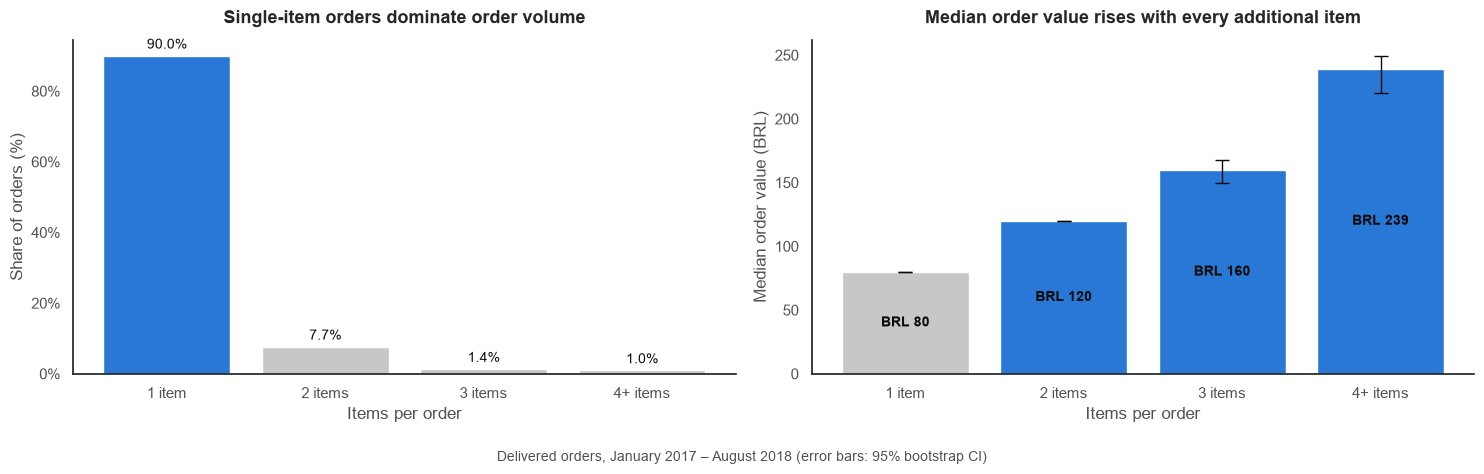

In [40]:
basket_ci = pd.DataFrame(
    [bootstrap_median_ci(group['order_value']) for _, group in
     orders_level_df.groupby('basket_group', observed=True)],
    index=basket_summary.index, columns=['median', 'ci_lower', 'ci_upper'],
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Left: share of orders per basket group.
axes[0].bar(basket_summary.index.astype(str), basket_summary['orders_pct'],
            color=[HIGHLIGHT, MUTED, MUTED, MUTED])
annotate_bars(axes[0], '{:.1f}%')
axes[0].set_title('Single-item orders dominate order volume')
axes[0].set_xlabel('Items per order')
axes[0].set_ylabel('Share of orders (%)')
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))

# Right: median order value with 95% bootstrap confidence interval.
axes[1].bar(basket_ci.index.astype(str), basket_ci['median'],
            color=[MUTED, HIGHLIGHT, HIGHLIGHT, HIGHLIGHT])
axes[1].errorbar(
    x=range(len(basket_ci)), y=basket_ci['median'],
    yerr=[basket_ci['median'] - basket_ci['ci_lower'], basket_ci['ci_upper'] - basket_ci['median']],
    fmt='none', ecolor=TEXT, capsize=5, linewidth=1,
)
annotate_bars(axes[1], 'BRL {:,.0f}', inside=True)
axes[1].set_title('Median order value rises with every additional item')
axes[1].set_xlabel('Items per order')
axes[1].set_ylabel('Median order value (BRL)')

fig.suptitle('Delivered orders, January 2017 – August 2018 (error bars: 95% bootstrap CI)',
             y=0.02, fontsize=10, color='#52514e')
plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.show()

In [41]:
# Kruskal-Wallis test: do order values differ across basket groups?
# (non-parametric, because order value is strongly right-skewed)
groups = [group['order_value'].values for _, group in orders_level_df.groupby('basket_group', observed=True)]
h_stat, p_value = stats.kruskal(*groups)
print(f'Kruskal-Wallis H = {h_stat:,.2f}, p-value = {p_value:.3g}')

single_median = orders_level_df.loc[~multi_item, 'order_value'].median()
multi_median = orders_level_df.loc[multi_item, 'order_value'].median()
print(f'Median order value: single-item {single_median:,.2f} BRL, multi-item {multi_median:,.2f} BRL')
print(f'Difference: {multi_median - single_median:,.2f} BRL ({multi_median / single_median - 1:.1%} higher)')

Kruskal-Wallis H = 3,296.75, p-value = 0
Median order value: single-item 79.90 BRL, multi-item 134.97 BRL
Difference: 55.07 BRL (68.9% higher)


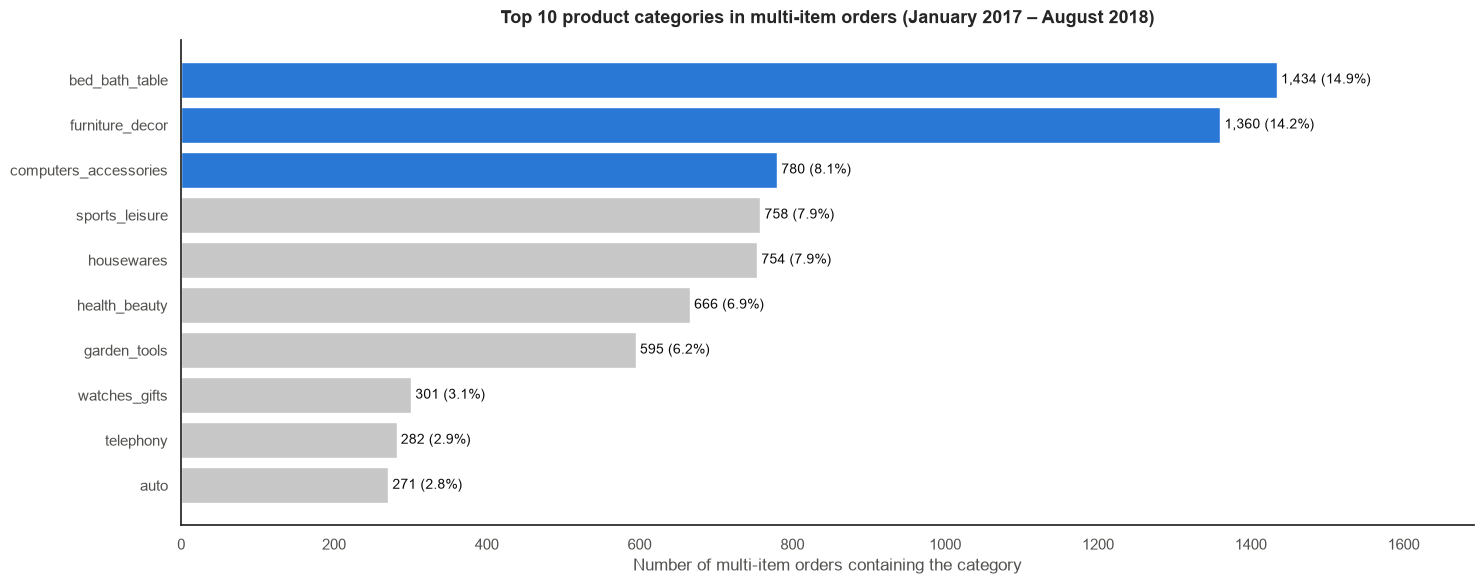

In [42]:
top_categories = category_multi_orders.head(10)

fig, ax = plt.subplots(figsize=(15, 6))
ax.barh(top_categories.index, top_categories['multi_item_orders'],
        color=[HIGHLIGHT] * 3 + [MUTED] * 7)
ax.invert_yaxis()
ax.bar_label(ax.containers[0],
             labels=[f'{n:,} ({p:.1f}%)' for n, p in
                     zip(top_categories['multi_item_orders'], top_categories['share_pct'])],
             padding=3, fontsize=10, color=TEXT)
ax.set_title('Top 10 product categories in multi-item orders (January 2017 – August 2018)')
ax.set_xlabel('Number of multi-item orders containing the category')
ax.set_ylabel(None)
ax.set_xlim(0, top_categories['multi_item_orders'].max() * 1.18)
plt.tight_layout()
plt.show()

**Insight:**
- **90.0%** of delivered orders contain a single item, so single-item orders define the typical transaction.
- Each additional item raises the median order value: 79.90 BRL → 119.80 BRL → 159.70 BRL → 239.40 BRL. The 95% confidence intervals do not overlap, so the increase is not explained by sampling variation.
- The median multi-item order (134.97 BRL) is **55.07 BRL (68.9%) higher** than the median single-item order (79.90 BRL). The Kruskal-Wallis test confirms that order value differs significantly between basket groups (H = 3,296.75, p < 0.001).
- `bed_bath_table` (1,434 orders), `furniture_decor` (1,360), and `computers_accessories` (780) are the categories that appear most often in multi-item orders, followed by `sports_leisure` (758) and `housewares` (754).

### 5.2. Pertanyaan 2: What percentage of customers are repeat customers, and how much more do they spend? (January 2017 – August 2018)

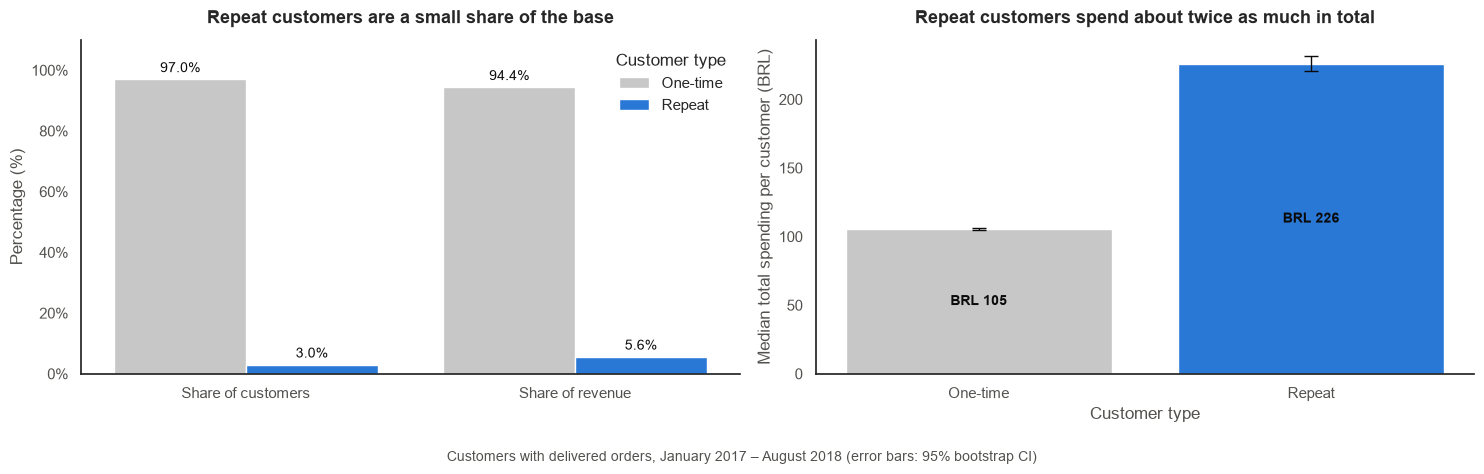

In [43]:
type_order = ['One-time', 'Repeat']
spending_ci = pd.DataFrame(
    [bootstrap_median_ci(customers_level_df.loc[customers_level_df['customer_type'] == t, 'total_spending'])
     for t in type_order],
    index=type_order, columns=['median', 'ci_lower', 'ci_upper'],
)
share_df = customer_type_summary.loc[type_order, ['customers_pct', 'revenue_pct']].reset_index().melt(
    id_vars='customer_type', var_name='metric', value_name='pct'
)
share_df['metric'] = share_df['metric'].map({'customers_pct': 'Share of customers',
                                             'revenue_pct': 'Share of revenue'})

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Left: share of customers vs. share of revenue.
sns.barplot(data=share_df, x='metric', y='pct', hue='customer_type', hue_order=type_order,
            palette=[MUTED, HIGHLIGHT], saturation=1, ax=axes[0])
annotate_bars(axes[0], '{:.1f}%')
axes[0].set_title('Repeat customers are a small share of the base')
axes[0].set_xlabel(None)
axes[0].set_ylabel('Percentage (%)')
axes[0].set_ylim(0, 110)
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))
axes[0].legend(title='Customer type', frameon=False)

# Right: median total spending per customer with 95% bootstrap confidence interval.
axes[1].bar(spending_ci.index, spending_ci['median'], color=[MUTED, HIGHLIGHT])
axes[1].errorbar(
    x=range(len(spending_ci)), y=spending_ci['median'],
    yerr=[spending_ci['median'] - spending_ci['ci_lower'], spending_ci['ci_upper'] - spending_ci['median']],
    fmt='none', ecolor=TEXT, capsize=5, linewidth=1,
)
annotate_bars(axes[1], 'BRL {:,.0f}', inside=True)
axes[1].set_title('Repeat customers spend about twice as much in total')
axes[1].set_xlabel('Customer type')
axes[1].set_ylabel('Median total spending per customer (BRL)')

fig.suptitle('Customers with delivered orders, January 2017 – August 2018 (error bars: 95% bootstrap CI)',
             y=0.02, fontsize=10, color='#52514e')
plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.show()

In [44]:
# Mann-Whitney U test: does total spending differ between one-time and repeat customers?
one_time_spending = customers_level_df.loc[customers_level_df['customer_type'] == 'One-time', 'total_spending']
repeat_spending = customers_level_df.loc[customers_level_df['customer_type'] == 'Repeat', 'total_spending']
u_stat, p_value = stats.mannwhitneyu(repeat_spending, one_time_spending, alternative='two-sided')
print(f'Mann-Whitney U = {u_stat:,.0f}, p-value = {p_value:.3g}')

repeat_pct = (customers_level_df['customer_type'] == 'Repeat').mean()
print(f'Repeat customers: {repeat_pct:.2%}')
print(f'Median total spending: one-time {one_time_spending.median():,.2f} BRL, '
      f'repeat {repeat_spending.median():,.2f} BRL '
      f'({repeat_spending.median() / one_time_spending.median() - 1:.1%} higher)')

Mann-Whitney U = 194,901,027, p-value = 0
Repeat customers: 3.00%
Median total spending: one-time 105.38 BRL, repeat 225.63 BRL (114.1% higher)


**Insight:**
- Only **3.0%** of customers placed more than one delivered order. Repeat customers generate 5.6% of payment value.
- The median repeat customer spent **225.63 BRL**, which is **120.25 BRL (114.1%) more** than the median one-time customer (105.38 BRL). The Mann-Whitney U test confirms that the difference is significant (U = 194,901,027, p < 0.001).
- Spending per order is almost equal for both groups (110.04 BRL vs. 105.38 BRL; see EDA 4.4), so the extra value of a repeat customer comes from additional orders. Most repeat customers (2,562 of 2,789) placed exactly two orders.

## 6. Analisis Lanjutan

### 6.1. RFM Analysis

**Purpose:** RFM analysis describes each customer's purchase behavior with three metrics, so the business can see which customers are valuable, which are still active, and which are drifting away:

* **Recency:** days between the customer's last purchase and the reference date (1 September 2018, the day after the analysis period ends).
* **Frequency:** number of delivered orders in the analysis period.
* **Monetary:** total payment value (BRL) in the analysis period.

In [45]:
REFERENCE_DATE = pd.Timestamp('2018-09-01')

rfm_df = orders_level_df.groupby('customer_unique_id').agg(
    last_purchase=('order_purchase_timestamp', 'max'),
    frequency=('order_id', 'nunique'),
    monetary=('payment_value', 'sum'),
)
rfm_df['recency'] = (REFERENCE_DATE - rfm_df['last_purchase']).dt.days
rfm_df = rfm_df[['recency', 'frequency', 'monetary']]
rfm_df.describe()

,recency,frequency,monetary
count,"93,104.00","93,104.00","93,104.00"
mean,238.24,1.03,165.15
std,150.95,0.21,226.38
min,2.00,1.00,9.59
25%,116.00,1.00,63.04
50%,220.00,1.00,107.78
75%,347.00,1.00,182.50
max,603.00,15.00,"13,664.08"


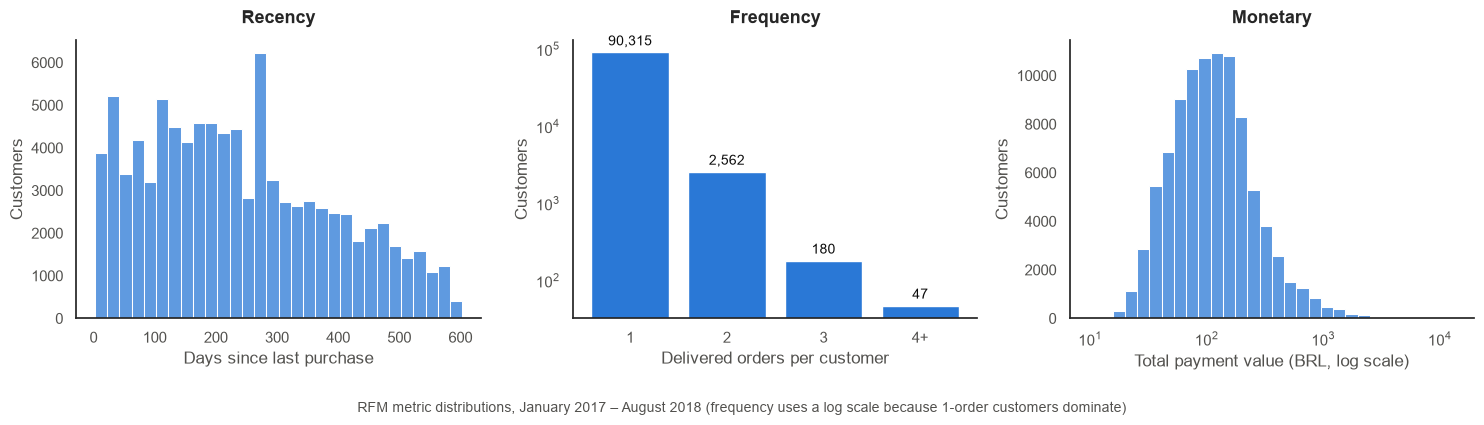

In [46]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

sns.histplot(rfm_df['recency'], bins=30, color=HIGHLIGHT, ax=axes[0])
axes[0].set_title('Recency')
axes[0].set_xlabel('Days since last purchase')
axes[0].set_ylabel('Customers')

frequency_counts = rfm_df['frequency'].clip(upper=4).value_counts().sort_index()
axes[1].bar(['1', '2', '3', '4+'], frequency_counts.values, color=HIGHLIGHT)
annotate_bars(axes[1])
axes[1].set_title('Frequency')
axes[1].set_xlabel('Delivered orders per customer')
axes[1].set_ylabel('Customers')
axes[1].set_yscale('log')

sns.histplot(rfm_df['monetary'], bins=30, log_scale=True, color=HIGHLIGHT, ax=axes[2])
axes[2].set_title('Monetary')
axes[2].set_xlabel('Total payment value (BRL, log scale)')
axes[2].set_ylabel('Customers')

fig.suptitle('RFM metric distributions, January 2017 – August 2018 '
             '(frequency uses a log scale because 1-order customers dominate)',
             y=0.02, fontsize=10, color='#52514e')
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()

**Insight:**
- **Recency:** the median customer last purchased 220 days before the reference date, and 25% of customers have not purchased for more than 347 days.
- **Frequency:** the mean is 1.03 orders, and 90,315 of 93,104 customers have exactly one order. Frequency therefore does not separate one-time customers from each other; recency and monetary value must do that.
- **Monetary:** the median customer spent 107.78 BRL, and the distribution is right-skewed (mean 165.15 BRL, maximum 13,664.08 BRL).

### 6.2. Customer Segmentation Based on RFM Scores

**Purpose:** group customers into segments with explicit definitions, so that each segment can be matched to a specific marketing action and its size and revenue can be measured.

1. **Scoring:** `pd.qcut` splits recency and monetary into quartile scores from 1 (lowest) to 4 (highest). Frequency cannot be split into quartiles because most customers have exactly one order, so `pd.cut` divides it into *one-time* and *repeat*.
2. **Segment rules:** the three scores are combined into six segments:

| Segment | Rule | Meaning |
| --- | --- | --- |
| Loyal High-Value | Repeat and M score ≥ 3 | Bought more than once and spends in the top half |
| Loyal | Repeat and M score ≤ 2 | Bought more than once with lower spending |
| New High-Value | One-time, R score ≥ 3, M score ≥ 3 | Recent first purchase with high spending |
| New Low-Value | One-time, R score ≥ 3, M score ≤ 2 | Recent first purchase with low spending |
| Lapsed High-Value | One-time, R score ≤ 2, M score ≥ 3 | Old single purchase with high spending |
| Lapsed Low-Value | One-time, R score ≤ 2, M score ≤ 2 | Old single purchase with low spending |

In [47]:
rfm_df['r_score'] = pd.qcut(rfm_df['recency'], q=4, labels=[4, 3, 2, 1]).astype(int)
rfm_df['m_score'] = pd.qcut(rfm_df['monetary'], q=4, labels=[1, 2, 3, 4]).astype(int)
rfm_df['f_group'] = pd.cut(rfm_df['frequency'], bins=[0, 1, np.inf], labels=['One-time', 'Repeat'])

is_repeat = rfm_df['f_group'] == 'Repeat'
is_recent = rfm_df['r_score'] >= 3
is_high_value = rfm_df['m_score'] >= 3
rfm_df['segment'] = np.select(
    [
        is_repeat & is_high_value,
        is_repeat,
        is_recent & is_high_value,
        is_recent,
        is_high_value,
    ],
    ['Loyal High-Value', 'Loyal', 'New High-Value', 'New Low-Value', 'Lapsed High-Value'],
    default='Lapsed Low-Value',
)

SEGMENT_ORDER = ['Loyal High-Value', 'Loyal', 'New High-Value', 'New Low-Value',
                 'Lapsed High-Value', 'Lapsed Low-Value']
segment_df = rfm_df.groupby('segment').agg(
    customers=('recency', 'count'),
    median_recency=('recency', 'median'),
    mean_frequency=('frequency', 'mean'),
    median_monetary=('monetary', 'median'),
    revenue=('monetary', 'sum'),
).reindex(SEGMENT_ORDER)
segment_df['customers_pct'] = segment_df['customers'] / segment_df['customers'].sum() * 100
segment_df['revenue_pct'] = segment_df['revenue'] / segment_df['revenue'].sum() * 100
segment_df

,customers,median_recency,mean_frequency,median_monetary,revenue,customers_pct,revenue_pct
segment,,,,,,,
Loyal High-Value,2455,199.00,2.13,250.28,"833,138.86",2.64,5.42
Loyal,334,213.00,2.02,85.07,"27,615.70",0.36,0.18
New High-Value,22477,116.00,1.00,178.34,"5,871,488.92",24.14,38.19
New Low-Value,22664,116.00,1.00,62.33,"1,428,135.55",24.34,9.29
Lapsed High-Value,21611,346.00,1.00,180.40,"5,711,177.54",23.21,37.14
Lapsed Low-Value,23563,350.00,1.00,63.36,"1,504,318.87",25.31,9.78


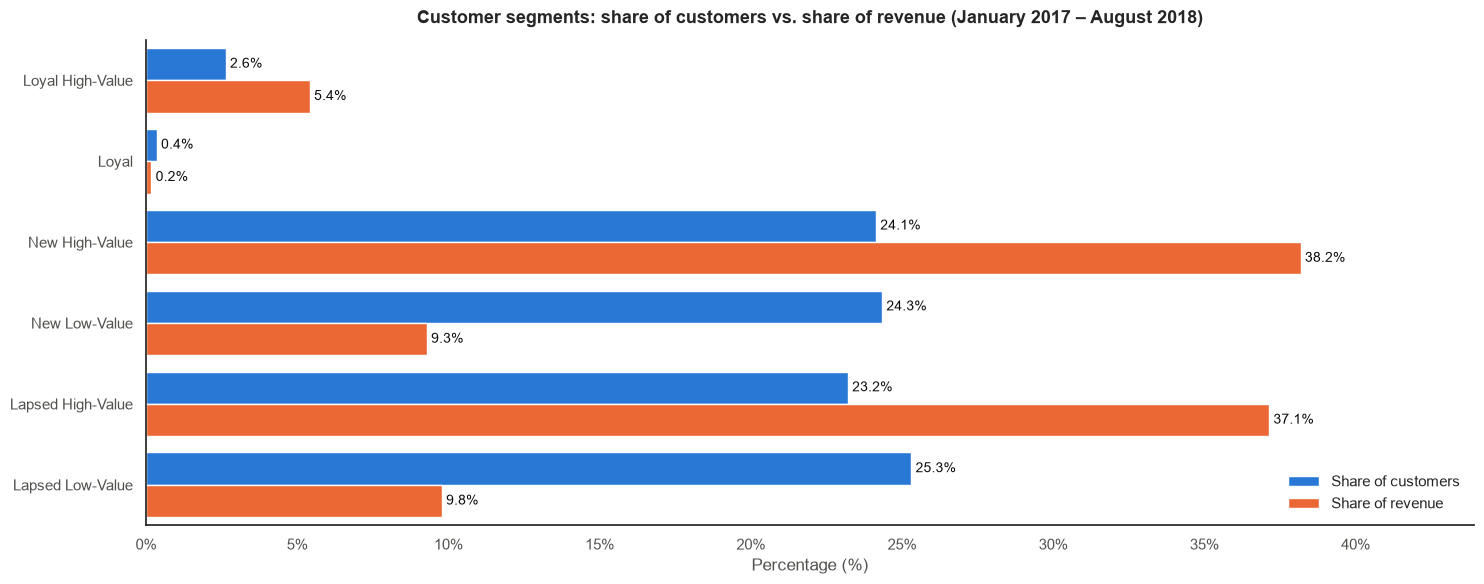

In [48]:
segment_share = segment_df[['customers_pct', 'revenue_pct']].reset_index().melt(
    id_vars='segment', var_name='metric', value_name='pct'
)
segment_share['metric'] = segment_share['metric'].map({'customers_pct': 'Share of customers',
                                                       'revenue_pct': 'Share of revenue'})

fig, ax = plt.subplots(figsize=(15, 6))
sns.barplot(data=segment_share, y='segment', x='pct', hue='metric', order=SEGMENT_ORDER,
            palette=[HIGHLIGHT, SECONDARY], saturation=1, ax=ax)
annotate_bars(ax, '{:.1f}%')
ax.set_title('Customer segments: share of customers vs. share of revenue (January 2017 – August 2018)')
ax.set_xlabel('Percentage (%)')
ax.set_ylabel(None)
ax.xaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))
ax.set_xlim(0, segment_share['pct'].max() * 1.15)
ax.legend(title=None, frameon=False, loc='lower right')
plt.tight_layout()
plt.show()

**Insight:**
- **Loyal High-Value** customers are 2.64% of customers but generate 5.42% of revenue, about twice their share.
- **New High-Value** (24.14% of customers, 38.19% of revenue) and **Lapsed High-Value** (23.21% of customers, 37.14% of revenue) together generate 75.33% of revenue.
- The **Lapsed High-Value** segment has 21,611 customers with a median spending of 180.40 BRL whose last purchase was a median of 346 days ago. It is the largest group of high-spending customers who have not purchased for about a year.
- The two low-value one-time segments contain 49.65% of customers but generate only 19.07% of revenue.

### 6.3. Geospatial Analysis

**Purpose:** show where customers and revenue are located, so that marketing and logistics decisions can be prioritized by region. Each order is placed on the map using the median coordinate of the customer's zip code prefix (prepared in Cleaning Data).

Orders with coordinates: 99.72%


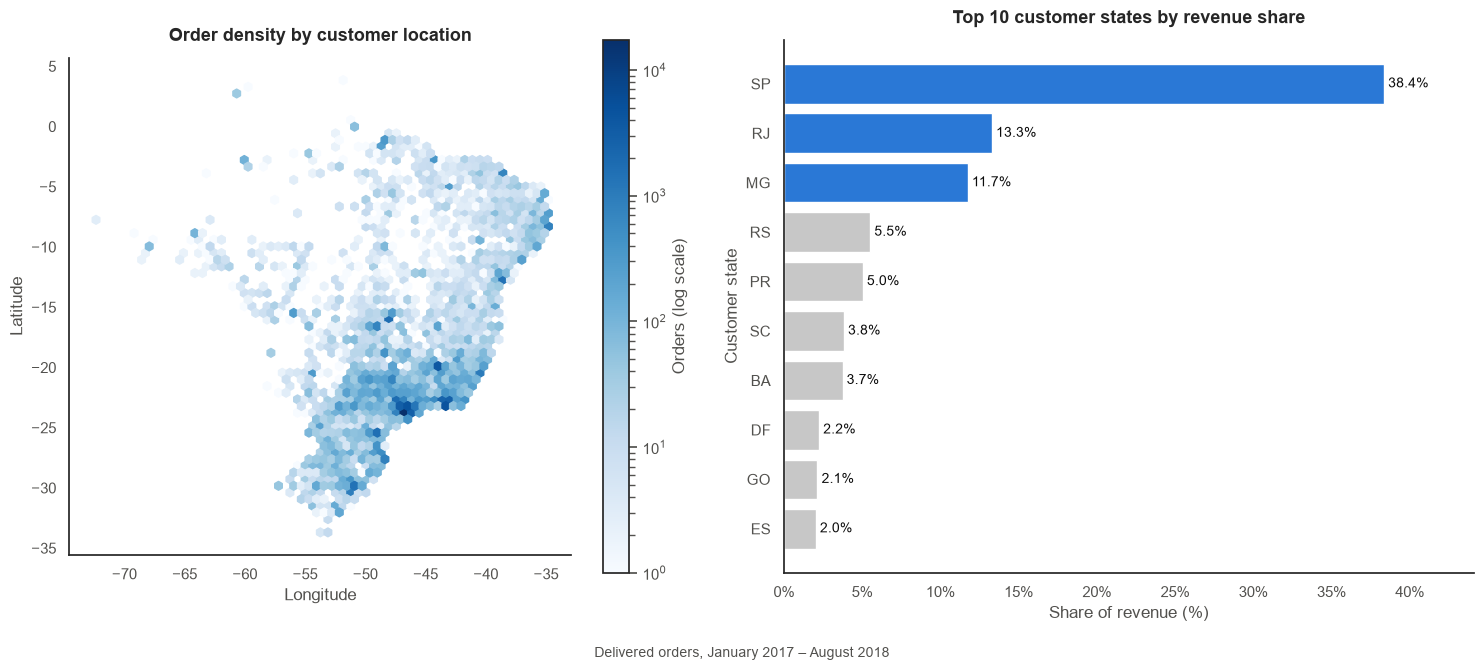

In [49]:
geo_orders_df = orders_level_df.merge(
    geolocation_df, left_on='customer_zip_code_prefix', right_on='geolocation_zip_code_prefix', how='left'
)
print(f'Orders with coordinates: {geo_orders_df["geolocation_lat"].notna().mean():.2%}')

fig, axes = plt.subplots(1, 2, figsize=(15, 7), gridspec_kw={'width_ratios': [1, 1.1]})

# Left: order density map (hexagonal bins, darker = more orders).
located = geo_orders_df.dropna(subset=['geolocation_lat'])
hb = axes[0].hexbin(located['geolocation_lng'], located['geolocation_lat'], gridsize=60,
                    bins='log', cmap='Blues', mincnt=1)
fig.colorbar(hb, ax=axes[0], label='Orders (log scale)')
axes[0].set_title('Order density by customer location')
axes[0].set_xlabel('Longitude')
axes[0].set_ylabel('Latitude')
axes[0].set_aspect('equal')

# Right: revenue share of the top 10 states.
top_states = state_df.head(10)
axes[1].barh(top_states.index, top_states['revenue_pct'], color=[HIGHLIGHT] * 3 + [MUTED] * 7)
axes[1].invert_yaxis()
annotate_bars(axes[1], '{:.1f}%')
axes[1].set_title('Top 10 customer states by revenue share')
axes[1].set_xlabel('Share of revenue (%)')
axes[1].set_ylabel('Customer state')
axes[1].xaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))
axes[1].set_xlim(0, top_states['revenue_pct'].max() * 1.15)

fig.suptitle('Delivered orders, January 2017 – August 2018', y=0.02, fontsize=10, color='#52514e')
plt.tight_layout(rect=[0, 0.03, 1, 1])
plt.show()

In [50]:
# Freight cost by state: median freight value and freight as a share of order value.
state_freight = geo_orders_df.groupby('customer_state').agg(
    orders=('order_id', 'count'),
    median_freight=('freight_value', 'median'),
    median_freight_ratio=('freight_value', lambda x: (x / geo_orders_df.loc[x.index, 'order_value']).median() * 100),
).sort_values('median_freight_ratio', ascending=False)
state_freight

,orders,median_freight,median_freight_ratio
customer_state,,,
RR,40,31.48,44.75
RO,243,38.52,39.29
AM,145,27.31,38.30
MA,713,35.46,38.29
PB,516,36.50,36.08
AC,80,39.16,35.81
SE,332,32.71,34.60
PA,942,28.91,34.19
TO,274,34.28,34.15


**Insight:**
- 99.72% of orders could be placed on the map. Orders are concentrated in the Southeast and South, especially around the São Paulo, Rio de Janeiro, and Belo Horizonte metropolitan areas. Orders are sparse in the North and in the interior of the Center-West.
- SP alone generates 38.4% of revenue, and SP, RJ, and MG together generate 63.4%.
- Freight is a much larger share of order value outside the Southeast. The median freight-to-order-value ratio is 18.71% in SP but between 32% and 45% in 14 of the 16 North and Northeast states (for example, RR 44.75%, RO 39.29%, AM 38.30%, and MA 38.29%).

### 6.4. Export Data for the Dashboard

The dashboard reads one file, `dashboard/main_data.csv`, with one row per item of the delivered orders in the analysis period. Order-level values (`item_count`, `order_value`, `freight_value`, `payment_value`) repeat on every item row of the same order, so the dashboard de-duplicates by `order_id` before computing order-level metrics.

In [51]:
main_data = (
    items_level_df[['order_id', 'product_category', 'price']]
    .merge(
        geo_orders_df[['order_id', 'customer_unique_id', 'order_purchase_timestamp', 'customer_city',
                       'customer_state', 'geolocation_lat', 'geolocation_lng', 'item_count',
                       'order_value', 'freight_value', 'payment_value']],
        on='order_id',
    )
    .round({'geolocation_lat': 4, 'geolocation_lng': 4, 'order_value': 2, 'payment_value': 2,
            'freight_value': 2})
)
main_data.to_csv('dashboard/main_data.csv', index=False)
print(main_data.shape)
main_data.head()

(109880, 13)


,order_id,product_category,price,customer_unique_id,order_purchase_timestamp,customer_city,customer_state,geolocation_lat,geolocation_lng,item_count,order_value,freight_value,payment_value
0,00010242fe8c5a6d1ba2dd792cb16214,cool_stuff,58.90,871766c5855e863f6eccc05f988b23cb,2017-09-13 08:59:02,campos dos goytacazes,RJ,-21.76,-41.31,1,58.90,13.29,72.19
1,00018f77f2f0320c557190d7a144bdd3,pet_shop,239.90,eb28e67c4c0b83846050ddfb8a35d051,2017-04-26 10:53:06,santa fe do sul,SP,-20.21,-50.93,1,239.90,19.93,259.83
2,000229ec398224ef6ca0657da4fc703e,furniture_decor,199.00,3818d81c6709e39d06b2738a8d3a2474,2018-01-14 14:33:31,para de minas,MG,-19.87,-44.59,1,199.00,17.87,216.87
3,00024acbcdf0a6daa1e931b038114c75,perfumery,12.99,af861d436cfc08b2c2ddefd0ba074622,2018-08-08 10:00:35,atibaia,SP,-23.11,-46.59,1,12.99,12.79,25.78
4,00042b26cf59d7ce69dfabb4e55b4fd9,garden_tools,199.90,64b576fb70d441e8f1b2d7d446e483c5,2017-02-04 13:57:51,varzea paulista,SP,-23.25,-46.83,1,199.90,18.14,218.04


## 7. Conclusion & Recommendation

- **Conclusion pertanyaan 1:** Between January 2017 and August 2018, the median delivered order with two or more items was worth **134.97 BRL**, which is **55.07 BRL (68.9%) higher** than the median single-item order (79.90 BRL). The difference is statistically significant (Kruskal-Wallis, p < 0.001), and the median rises with every additional item (119.80 BRL for 2 items, 159.70 BRL for 3, and 239.40 BRL for 4+). However, only 9.98% of orders contained more than one item, and this share stayed between 8.58% and 12.00% every month. The categories that appear most often in multi-item orders are **`bed_bath_table` (14.9%)**, **`furniture_decor` (14.2%)**, and **`computers_accessories` (8.1%)**. In 91.9% of multi-item orders, all items come from one category.
- **Conclusion pertanyaan 2:** Between January 2017 and August 2018, only **3.00% of customers (2,789 of 93,104)** placed more than one delivered order. The median total spending of repeat customers was **225.63 BRL**, which is **120.25 BRL (114.1%) higher** than that of one-time customers (105.38 BRL). The difference is statistically significant (Mann-Whitney U, p < 0.001). Spending per order is almost the same in both groups (110.04 BRL vs. 105.38 BRL), so the higher value of repeat customers comes from purchase frequency.

**Rekomendasi Action Item:**
- **Bundles in the top multi-item categories (Pertanyaan 1):** create "complete the set" bundles and quantity discounts in `bed_bath_table`, `furniture_decor`, and `computers_accessories` (for example, bed sheet and towel sets, matching decor items, and accessory kits). Track the monthly share of multi-item orders against the 8.58%–12.00% baseline.
- **Free-shipping threshold above a single item (Pertanyaan 1):** set a free-shipping or discount threshold around 120 BRL, the median value of a 2-item order and above the 79.90 BRL single-item median, so that adding a second item becomes worthwhile.
- **Cross-category suggestions at checkout (Pertanyaan 1):** only 8.1% of multi-item orders combine categories. Pair complementary categories, such as `bed_bath_table` with `furniture_decor` or `housewares`, on product and cart pages.
- **Second-purchase program (Pertanyaan 2):** send new customers (the New High-Value and New Low-Value segments, 45,141 customers) a time-limited voucher for their second order, because a repeat customer's extra value comes from additional orders.
- **Win-back campaign for Lapsed High-Value customers (RFM segmentation):** target the 21,611 customers who spent a median of 180.40 BRL but have not purchased for a median of 346 days. Start with SP, RJ, and MG, which generate 63.4% of revenue.
- **Freight review for the North and Northeast (geospatial analysis):** the median freight is 32%–45% of order value in 14 of the 16 states in these regions, compared with 18.7% in SP. Evaluate regional shipping subsidies or partner carriers to make orders from these regions more competitive.